# Group 42

Main

A* path length = 37
[(40, 10), (39, 11), (38, 12), (37, 13), (36, 14), (35, 15), (34, 16), (33, 17), (32, 18), (31, 19), (30, 20), (29, 21), (28, 22), (27, 23), (26, 24), (26, 25), (25, 26), (24, 27), (23, 28), (22, 29), (22, 30), (21, 31), (20, 31), (19, 31), (18, 32), (17, 33), (16, 34), (15, 35), (14, 36), (13, 37), (12, 38), (11, 39), (10, 39), (9, 39), (8, 39), (7, 39), (6, 39), (5, 40)]


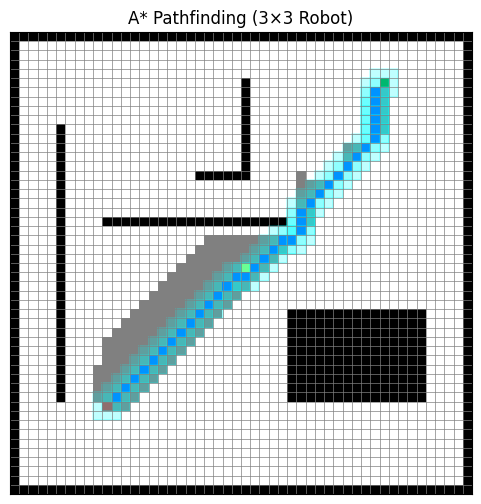

Thymio connected


NodeLockError: Node lock error (current status: busy)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio

from thymio import Thymio

# import vision
import motion_controll
# import filtering
import local_nav
import global_nav

thymio = Thymio(pos_init=[0, 0], orient=0)
await thymio._connect_to_thymio_()
thymio.stop()

Local nav tests

In [ ]:
thymio.nav_mode = "LOCAL"
while True: 
    await thymio.update_ir()
    # is_object = local_nav.is_object(thymio)
    # if(is_object):
    #     print("object detected")
    print(str(thymio.ir_sensors) + "                     ", end="\r")
    avoid_right = local_nav.avoid_right(thymio, grid)
    local_nav.avoid_obstacle(thymio, 0, 0, avoid_right)
# await thymio.update_ir()
# print(thymio.ir_sensors)

Motion controll testing

In [2]:
thymio.stop()

In [ ]:
thymio.pos = [20,20]
thymio.orient = 0
goal = [22,25]
print(motion_controll.follow_path(thymio, goal))

angle_speed: 162.666476215536, left_speed: 37, right_speed: 362
False


In [2]:
await thymio.unlock()

Thymio unlocked


## Main Loop

In [ ]:
# External modules import
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio

# Internal modules and thymio class import
from thymio import Thymio
import vision
import motion_controll
import filtering
import local_nav
import global_nav

# Constants
GL_NAV_CHANGE_THLD = 20

# Initalisation of the grid
end_pos, grid = vision.init_grid()

# Get start position and orientation
start_pos, start_orient = vision.get_pos()

# Find the path to goal
path = global_nav.find_path()

# Initialisation of the thymio and connextion
thymio = Thymio(pos_init=start_pos, orient=start_orient)
await thymio._connect_to_thymio_()


gl_nav_change_cntr = 0

while(True):
    thymio.update_ir()
    print(thymio.ir_sensors)
    is_object = local_nav.is_object(thymio)
    nav_mode_change = False
    
    if(not is_object and thymio.nav_mode=="LOCAL"):
        gl_nav_change_cntr += 1
        if(gl_nav_change_cntr => GL_NAV_CHANGE_THLD):
            nav_mode_change = True
            thymio.nav_mode = "GLOBAL"
            path = global_nav.find_path()

    if(is_object):
        gl_nav_change_cntr = 0
        if(thymio.nav_mode=="GLOBAL"):
            nav_mode_change = True
            thymio.nav_mode = "LOCAL"
        local_nav.avoid_obstacle(thymio, grid=grid, path=path)
    
    if(thymio.nav_mode=="GLOBAL"):
        next_wp = path[0]
        wp_reached = motion_controll.follow_path(thymio, next_wp)
        if(wp_reached):
            path.pop(0)  # Supprime le waypoint atteint
            if len(path) == 0:  # Si plus de waypoints
                print("Destination atteinte!")
                break  # Sortir de la boucle
    
    pos_on_img, orient_on_img = vision.get_pos()
    filtering.filter_pos(thymio, pos_on_img, orient_on_img)



Thymio connected
[0, 0, 0, 0, 0]
[0, 0, 0, 0, 0]
[0, 0, 0, 0, 0]
Destination atteinte!


C:\Users\abart\AppData\Local\Temp\ipykernel_33416\3937944184.py:22: RuntimeWarning: coroutine 'Thymio.update_ir' was never awaited
  thymio.update_ir()


In [10]:
a = [[1,2],[3,4]]
a[1][1]

4

In [ ]:
await thymio.update_ir()
print(thymio.ir_sensors[0:5])

In [4]:
thymio.set_motor_speeds([100, 100])
while True:
    await thymio.update_ir()
    if sum(thymio.ir_sensors) > 2000:
        thymio.stop()
        break
    

Next cell makes the Thymio robot move forward for 4 seconds and then stops each time the Forward button is pressed. Program stops when the Backward button is pressed.  
It is intended to collect data for computing the **velocity variance**.

In [5]:
await thymio.button_loop()

Forward pressed
Center pressed
Backward pressed


Using this program to measure (with a ruler) the distance travelled by the bot each time to see differencies despite constant time and compute the variance on speed state.

In [ ]:
data_velocity_error=[160, 161, 159] #distances in mm travelled at presumed same speed for a constant time
data_velocity_error/=4 #distances divided by the constant time to get true velocities

q_v = np.var(data_velocity_error) # variance on speed state

From the camera we get a data set of XY position measurements from the same position to search for some differencies and compute variances on XY states and measurements.

In [ ]:
measurements_from_camera=np.array[[]]
x_measurements = [x[0] for x in measurements_from_camera]
y_measurements = [y[1] for y in measurements_from_camera]

var_x = np.var(x_measurements)
var_y = np.var(y_measurements)

q_x = var_x/2 #variance on x position state
r_x = var_x/2 #variance on x position measurement
q_y = var_y/2 #variance on y position state
r_y = var_y/2 #variance on y position measurement

In [6]:
def get_vector_from_circles(image):

    detector = cv2.SimpleBlobDetector_create()
    circle_centers = detector.detect(image)
    p1 = np.array(circle_centers[0].pt)
    p2 = np.array(circle_centers[1].pt)
    return p2-p1

In [7]:
def test_get_vector_from_circles(image):
    return [0,0]

In [ ]:
thymio.set_motor_speeds([0,0])
# ToDo: start camera
image = 0 #ToDo
delta_t = 2
start_time=0
k=1
data_vectors_pos=np.zeros((k, 2, 2))
data_vectors_neg=np.zeros((k, 2, 2))
for i in range(k):

    data_vectors_pos[i][0]=test_get_vector_from_circles(image)
    thymio.set_motor_speeds([100,-100])
    start_time=time.time()
    while True:
        if time.time() - start_time >=delta_t:
            thymio.set_motor_speeds([0,0])
            break
    data_vectors_pos[i][1]=test_get_vector_from_circles(image)
    data_vectors_neg[i][0]=test_get_vector_from_circles(image)

    thymio.set_motor_speeds([-100,100])
    start_time=time.time()
    while True:
        if time.time() - start_time >=delta_t:
            thymio.set_motor_speeds([0,0])
            break
    data_vectors_neg[i][1]=test_get_vector_from_circles(image)
    
    

KeyboardInterrupt: 